# Qiskit Benchmark Results
Plots for `output_gate_count_2q` and `output_depth_2q` across benchmark runs.

In [ ]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

BENCH_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.path.abspath('.'))),
    '.benchmarks/Darwin-CPython-3.14-64bit'
)

def load_file(filename):
    path = os.path.join(BENCH_DIR, filename)
    with open(path, encoding='utf-8') as f:
        return json.load(f)

# Load all summit runs
run2 = load_file('0002_qiskit-test-summit.json\xa0.json')
run3 = load_file('0003_qiskit-test-summit.json\xa0.json')
run4 = load_file('0004_qiskit-test-summit.json\xa0.json')

EXCLUDE = {'test_BVlike_simplification'}  # removed in run4, excluded from all runs

def extract_metrics(data):
    rows = []
    for b in data['benchmarks']:
        name = b['name'].replace('_transpile', '')
        if name in EXCLUDE:
            continue
        ei = b.get('extra_info', {})
        rows.append({
            'name': name,
            'gate_count_2q': ei.get('output_gate_count_2q'),
            'depth_2q': ei.get('output_depth_2q'),
            'time': b['stats']['mean'],
            'datetime': data['datetime'],
        })
    return rows

metrics2 = extract_metrics(run2)
metrics3 = extract_metrics(run3)
metrics4 = extract_metrics(run4)

names2 = {r['name']: r for r in metrics2}
names3 = {r['name']: r for r in metrics3}
names4 = {r['name']: r for r in metrics4}

# Use names present in all three runs
common_names = [r['name'] for r in metrics2 if r['name'] in names3 and r['name'] in names4]

print(f"Run 2: {run2['datetime'][:19]}")
print(f"Run 3: {run3['datetime'][:19]}")
print(f"Run 4: {run4['datetime'][:19]}")
print(f"Benchmarks ({len(common_names)}): {common_names}")

Run 2: 2026-03-13T09:46:06
Run 3: 2026-03-13T10:16:02
Run 4: 2026-03-13T10:44:33
Benchmarks (8): ['test_QFT_100', 'test_QV_100', 'test_circSU2_89', 'test_circSU2_100', 'test_BV_100', 'test_square_heisenberg_100', 'test_QAOA_100', 'test_clifford_100']


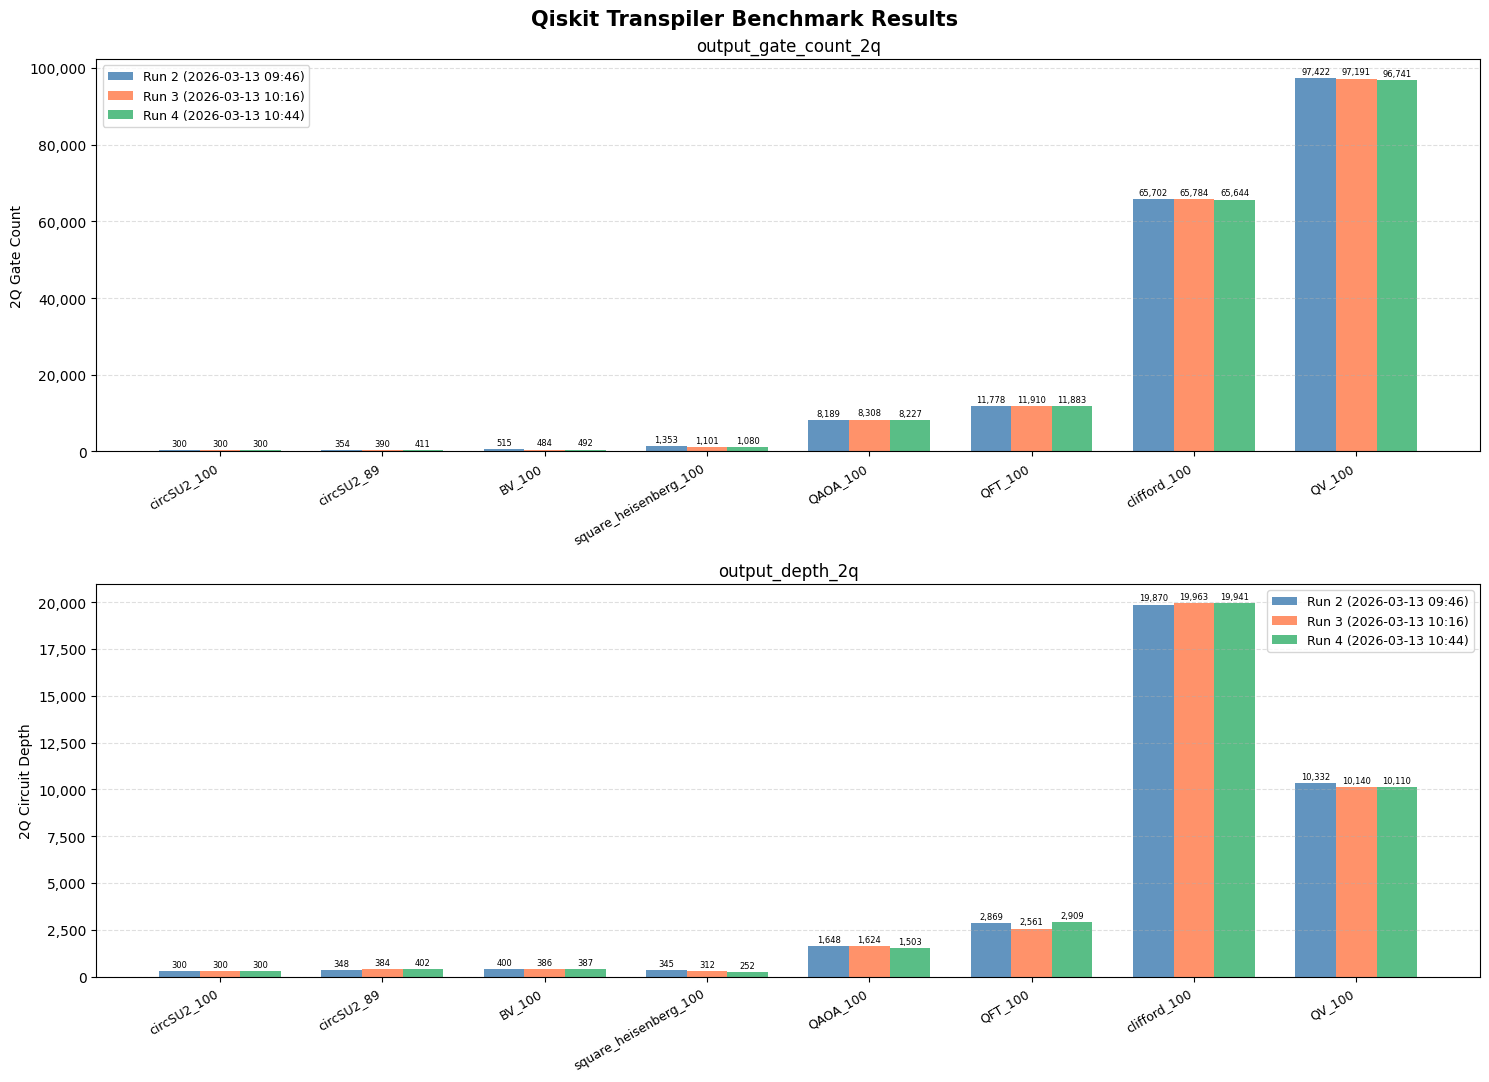

Saved: benchmark_2q_metrics.png


In [2]:
# Sort by average gate_count_2q across all runs (ascending)
sort_order = sorted(range(len(common_names)), key=lambda i: (
    names2[common_names[i]]['gate_count_2q'] +
    names3[common_names[i]]['gate_count_2q'] +
    names4[common_names[i]]['gate_count_2q']
) / 3)
common_names = [common_names[i] for i in sort_order]

short_names = [n.replace('test_', '') for n in common_names]

gc2 = [names2[n]['gate_count_2q'] for n in common_names]
gc3 = [names3[n]['gate_count_2q'] for n in common_names]
gc4 = [names4[n]['gate_count_2q'] for n in common_names]
d2  = [names2[n]['depth_2q'] for n in common_names]
d3  = [names3[n]['depth_2q'] for n in common_names]
d4  = [names4[n]['depth_2q'] for n in common_names]

x = np.arange(len(common_names))
width = 0.25

label2 = run2['datetime'][:16].replace('T', ' ')
label3 = run3['datetime'][:16].replace('T', ' ')
label4 = run4['datetime'][:16].replace('T', ' ')

fig, axes = plt.subplots(2, 1, figsize=(15, 11))
fig.suptitle('Qiskit Transpiler Benchmark Results', fontsize=15, fontweight='bold', y=0.98)

def annotate_bars(ax, bars):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{int(h):,}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 3), textcoords='offset points', ha='center', fontsize=6)

# --- Gate count 2Q ---
ax = axes[0]
b2 = ax.bar(x - width, gc2, width, label=f'Run 2 ({label2})', color='steelblue', alpha=0.85)
b3 = ax.bar(x,         gc3, width, label=f'Run 3 ({label3})', color='coral',     alpha=0.85)
b4 = ax.bar(x + width, gc4, width, label=f'Run 4 ({label4})', color='mediumseagreen', alpha=0.85)
ax.set_title('output_gate_count_2q', fontsize=12)
ax.set_ylabel('2Q Gate Count')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bars in (b2, b3, b4):
    annotate_bars(ax, bars)

# --- Depth 2Q ---
ax2 = axes[1]
b2d = ax2.bar(x - width, d2, width, label=f'Run 2 ({label2})', color='steelblue', alpha=0.85)
b3d = ax2.bar(x,         d3, width, label=f'Run 3 ({label3})', color='coral',     alpha=0.85)
b4d = ax2.bar(x + width, d4, width, label=f'Run 4 ({label4})', color='mediumseagreen', alpha=0.85)
ax2.set_title('output_depth_2q', fontsize=12)
ax2.set_ylabel('2Q Circuit Depth')
ax2.set_xticks(x)
ax2.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
for bars in (b2d, b3d, b4d):
    annotate_bars(ax2, bars)

plt.tight_layout()
plt.savefig('benchmark_2q_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_2q_metrics.png')

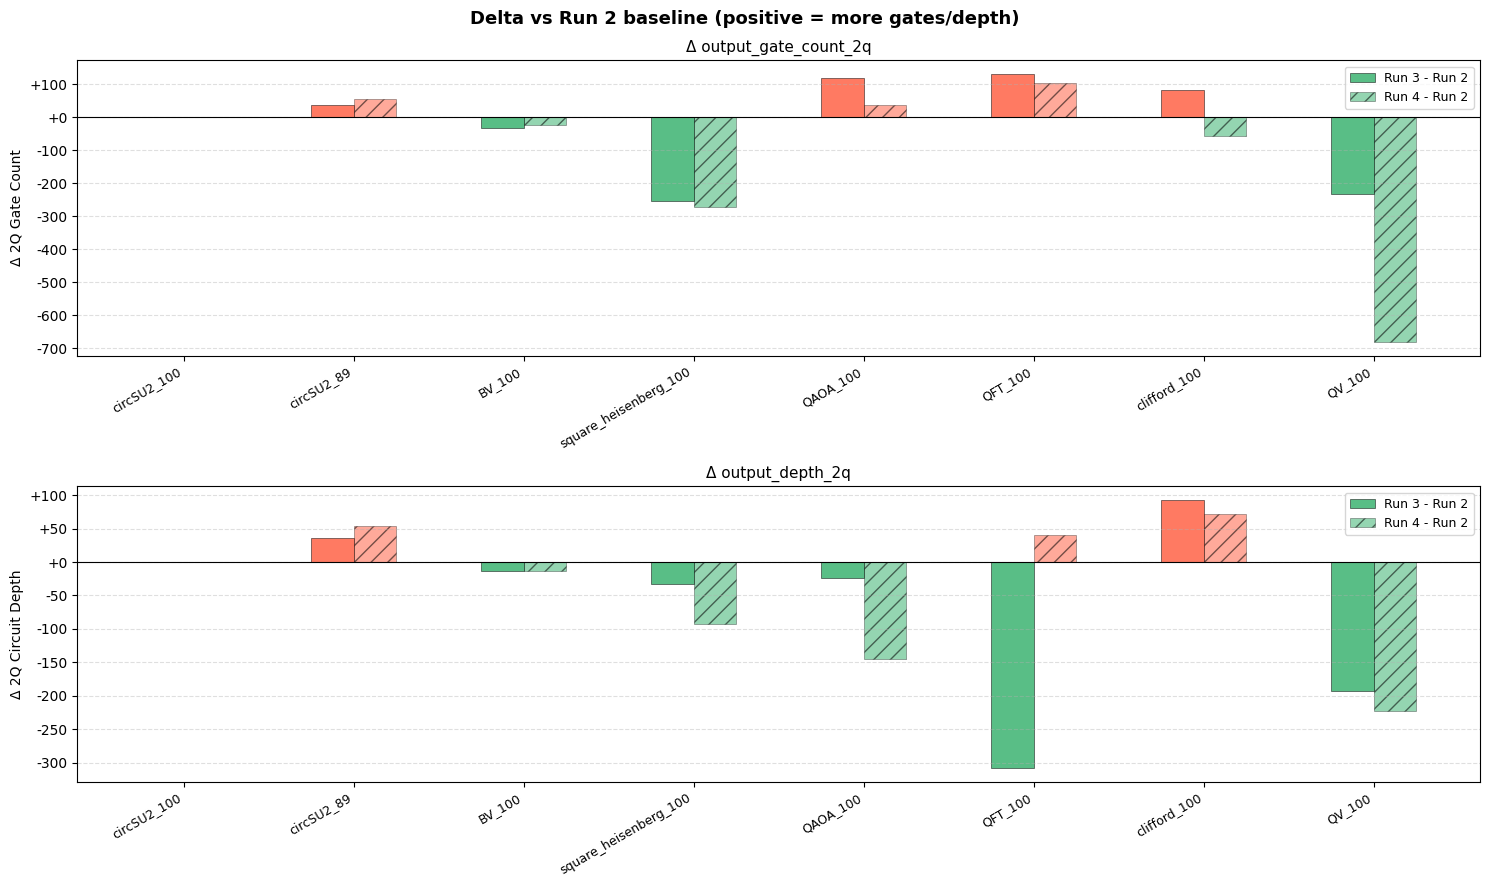

Saved: benchmark_2q_delta.png


In [3]:
# Delta view: each run vs run2 baseline
delta_gc3 = [gc3[i] - gc2[i] for i in range(len(common_names))]
delta_gc4 = [gc4[i] - gc2[i] for i in range(len(common_names))]
delta_d3  = [d3[i]  - d2[i]  for i in range(len(common_names))]
delta_d4  = [d4[i]  - d2[i]  for i in range(len(common_names))]

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
fig.suptitle('Delta vs Run 2 baseline (positive = more gates/depth)', fontsize=13, fontweight='bold')

def bar_colors(values):
    return ['tomato' if v > 0 else 'mediumseagreen' for v in values]

# --- Δ Gate count 2Q ---
ax = axes[0]
ax.bar(x - width/2, delta_gc3, width, label=f'Run 3 - Run 2', color=bar_colors(delta_gc3), alpha=0.85, edgecolor='black', linewidth=0.4)
ax.bar(x + width/2, delta_gc4, width, label=f'Run 4 - Run 2', color=bar_colors(delta_gc4), alpha=0.55, edgecolor='black', linewidth=0.4, hatch='//')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Δ output_gate_count_2q', fontsize=11)
ax.set_ylabel('Δ 2Q Gate Count')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):+,}'))
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# --- Δ Depth 2Q ---
ax2 = axes[1]
ax2.bar(x - width/2, delta_d3, width, label=f'Run 3 - Run 2', color=bar_colors(delta_d3), alpha=0.85, edgecolor='black', linewidth=0.4)
ax2.bar(x + width/2, delta_d4, width, label=f'Run 4 - Run 2', color=bar_colors(delta_d4), alpha=0.55, edgecolor='black', linewidth=0.4, hatch='//')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Δ output_depth_2q', fontsize=11)
ax2.set_ylabel('Δ 2Q Circuit Depth')
ax2.set_xticks(x)
ax2.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):+,}'))
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('benchmark_2q_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_2q_delta.png')

/var/folders/09/h3qq95w96xn1yknxjv71z0rm0000gn/T/ipykernel_88487/248869853.py:18: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  'circSU2_89':           EfficientSU2(89, reps=3, entanglement="circular"),
/var/folders/09/h3qq95w96xn1yknxjv71z0rm0000gn/T/ipykernel_88487/248869853.py:19: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  'circSU2_100':          EfficientSU2(100, reps=3, entanglement="circular"),


SWAP counts per summit circuit (pre-transpilation):
  QFT_100                    0
  QV_100                     0
  circSU2_89                 0
  circSU2_100                0
  BV_100                     0
  sq_heisenberg_100          0
  QAOA_100                   0
  clifford_100              70


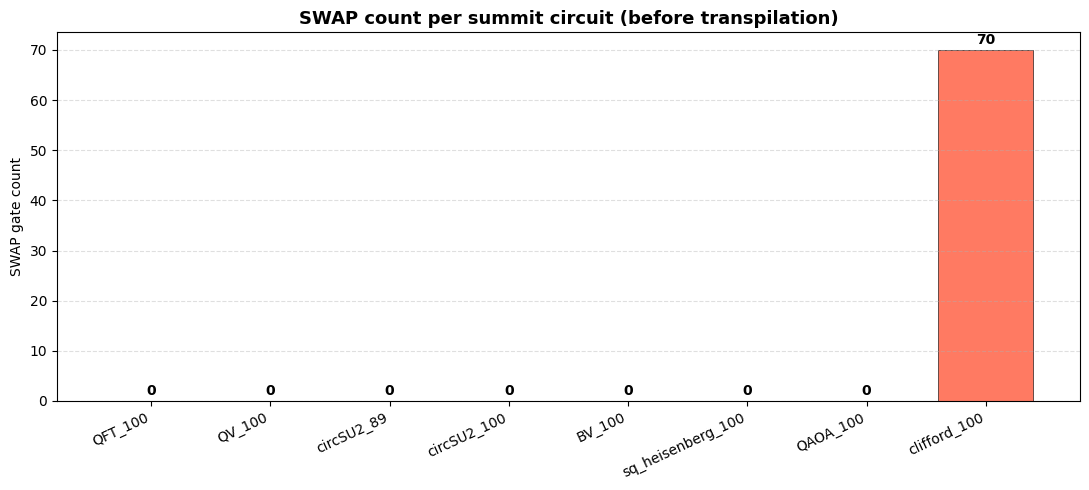

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import EfficientSU2

QASM_DIR = os.path.abspath(os.path.join('..', '..', 'benchpress', 'qasm'))

def load_qasm(path):
    return QuantumCircuit.from_qasm_file(path)

def swap_count(qc):
    return sum(1 for inst in qc.data if inst.operation.name.lower() == 'swap')

circuits = {
    'QFT_100':              load_qasm(f"{QASM_DIR}/qft/qft_N100.qasm"),
    'QV_100':               load_qasm(f"{QASM_DIR}/qv/qv_N100_12345.qasm"),
    'circSU2_89':           EfficientSU2(89, reps=3, entanglement="circular"),
    'circSU2_100':          EfficientSU2(100, reps=3, entanglement="circular"),
    'BV_100':               load_qasm(f"{QASM_DIR}/bv/bv_N100_12345.qasm") if os.path.exists(f"{QASM_DIR}/bv/bv_N100_12345.qasm") else None,
    'sq_heisenberg_100':    load_qasm(f"{QASM_DIR}/square-heisenberg/square_heisenberg_N100.qasm"),
    'QAOA_100':             load_qasm(f"{QASM_DIR}/qaoa/qaoa_barabasi_albert_N100_3reps.qasm"),
    'clifford_100':         load_qasm(f"{QASM_DIR}/clifford/clifford_100_12345.qasm"),
}

# BV is generated programmatically if no QASM exists
if circuits['BV_100'] is None:
    import sys
    sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))
    from benchpress.qiskit_gym.circuits import bv_all_ones
    circuits['BV_100'] = bv_all_ones(100)

names = list(circuits.keys())
counts = [swap_count(qc) for qc in circuits.values()]

print("SWAP counts per summit circuit (pre-transpilation):")
for n, c in zip(names, counts):
    print(f"  {n:<22} {c:>5}")

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in counts]
bars = ax.bar(names, counts, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.set_title('SWAP count per summit circuit (before transpilation)', fontsize=13, fontweight='bold')
ax.set_ylabel('SWAP gate count')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=25, ha='right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bar, c in zip(bars, counts):
    ax.annotate(str(c), xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
#plt.savefig('summit_swap_counts.png', dpi=150, bbox_inches='tight')
plt.show()
#print('Saved: summit_swap_counts.png')